# Using a conditional WGAN-GP to generate data
In this notebook we use a WGAN-GP with a conditional to try to create synthetic data from our ring of 8 disk-like clusters. As in the conditional GAN we use the center points and labels as our conditional data.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from gan.models import Generator, Discriminator
from gan.training import train_wgan_gp

#### Creating Data
Since we are using a condtional WGAN-GP here, when we create data we again also return labels and centers so we can use that for the conditional data.

In [3]:
# create a dataset with disk like clusters centered around the origin

def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Parameters
    ----------
    n_samples : int
        number of samples
    centers : int 
        number of disk clusters
    radius : float
        radius of ring containing centers of the clusters
    std : float
        standard deviation for distance from center of disk for a point
    seed : int
        random seed to use
    Returns
    -------
    tuple
        array of sample points, array of cluster centers for each point, array of labels for each cluster
    """
    rng = np.random.default_rng(seed)
    # compute the centers of each cluster
    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    sample_labels = []
    sample_centers = []
    # choose a random center and a random point in the cluster
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        # add the center and label
        sample_labels.append(k)
        sample_centers.append(means[k])
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32), np.array(sample_labels), np.array(sample_centers,dtype=np.float32)

##### Now we generate data and one-hot encode the labels to use for the condtional

In [4]:
# Get the data the array of labels and array of centers
X, c_label, c_center = make_gaussian_mixture()

In [5]:
# one hot encode the labels
one_hot = torch.nn.functional.one_hot(torch.tensor(c_label), num_classes=8).float()

For the WGAN-GP we wish to scale the data to the range of $[-1,1]$. Since the centers in the conditional data are on the same scale as the data, we scale the centers as well

In [6]:
# scale the data and centers to ranges of [-1,1]
X_min, X_max = X.min(axis=0), X.max(axis=0)
X_scaled = 2 * (X-X_min) / (X_max - X_min) - 1
c_center_scaled = 2 * (c_center - X_min)/(X_max - X_min) - 1

In [7]:
# combine the scaled centers and one hot encoded labels as the conditional vector
c = torch.cat([torch.tensor(c_center_scaled), one_hot], dim=1)

#### Training
For this we create a Generator with final output activation of $\tanh$ to scale the output to $[-1,1]$
The critic is created using our Discriminator class. We then train on the data.

In [8]:
G = Generator(
    noise_dim = 2,
    num_hidden_layers = 2,
    out_dim = 2,
    hidden_dims=(128,128),
    output_activation=nn.Tanh,
    use_conditional=True,
    conditional_dim=c.shape[1]
)

In [9]:
D = Discriminator(
    feature_dim=2,
    num_hidden_layers=2,
    hidden_dims=(128,128),
    use_conditional=True,
    conditional_dim=c.shape[1]
)

In [11]:
# train G,D using c 
train_wgan_gp(
    X=torch.tensor(X_scaled),
    G=G,
    D=D,
    c=c
)

Epoch 10/200 | D loss: 0.0606 | G loss: -5.1056
Epoch 20/200 | D loss: 0.0460 | G loss: -0.8284
Epoch 30/200 | D loss: 0.0476 | G loss: -0.5004
Epoch 40/200 | D loss: 0.0491 | G loss: -0.3660
Epoch 50/200 | D loss: 0.0494 | G loss: 0.6446
Epoch 60/200 | D loss: 0.0593 | G loss: 1.0724
Epoch 70/200 | D loss: 0.0496 | G loss: 1.7604
Epoch 80/200 | D loss: 0.0398 | G loss: 2.8205
Epoch 90/200 | D loss: 0.0365 | G loss: 2.2534
Epoch 100/200 | D loss: 0.0318 | G loss: 1.7468
Epoch 110/200 | D loss: 0.0343 | G loss: 2.0659
Epoch 120/200 | D loss: 0.0600 | G loss: 2.3278
Epoch 130/200 | D loss: 0.0343 | G loss: 1.2859
Epoch 140/200 | D loss: 0.0404 | G loss: 0.4143
Epoch 150/200 | D loss: 0.0197 | G loss: -0.3947
Epoch 160/200 | D loss: 0.0531 | G loss: 0.4649
Epoch 170/200 | D loss: 0.0241 | G loss: 3.1245
Epoch 180/200 | D loss: 0.0283 | G loss: 3.3932
Epoch 190/200 | D loss: 0.0258 | G loss: 5.5153
Epoch 200/200 | D loss: 0.0201 | G loss: 3.6543


#### Visualization
We generate an equal length version of synthetic data using the same conditional and plot both the real and synthetic data on the same axes.

In [ ]:

@torch.no_grad()
def plot_samples(G, X_real,c = None, n=2000, title = None):
    """
    Plot sample points from the real data and fake data from the generator
    Parameters
    ----------
    G: Generator
        generator to create random samples
    X_real : np.ndarray
        array of real data
    c : torch.Tensor | None
        if not None, the conditional array to be used for generating data
    n : int
        number of sample points in each set to plot
    title : str | None
        when not None title for the plot
    """
    # get the first n conditional rows (if using a conditional)
    if c is not None:
        c_input = c[:n]
    else: 
        c_input = None
    
    # generate n fake data points
    X_fake = G.generate(n,c_input).cpu().numpy()
    # undo the scaling
    X_fake_unscaled = (X_fake + 1) / 2 * (X_max - X_min) + X_min
    plt.figure(figsize=(5,5))
    plt.scatter(X_real[:n,0], X_real[:n,1], s=5, alpha=0.3, label="Real")
    plt.scatter(X_fake_unscaled[:,0], X_fake_unscaled[:,1], s=5, alpha=0.3, label="Fake")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.show()

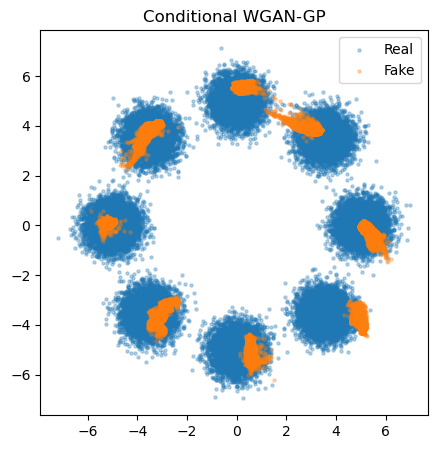

In [12]:
# generate a fake data set with the same size as the original and plot
plot_samples(G, X, c, len(X), "Conditional WGAN-GP")